In [0]:
import warnings 
warnings.filterwarnings('ignore')

## K-Nearest-Neighbors

KNN falls in the supervised learning family of algorithms. Informally, this means that we are given a labelled dataset consiting of training observations (x,y) and would like to capture the relationship between x and y. More formally, our goal is to learn a function h:X→Y so that given an unseen observation x, h(x) can confidently predict the corresponding output y.

In this module we will explore the inner workings of KNN, choosing the optimal K values and using KNN from scikit-learn.

## Overview

1.Read the problem statement.

2.Get the dataset.

3.Explore the dataset.

4.Pre-processing of dataset.

5.Visualization

6.Transform the dataset for building machine learning model.

7.Split data into train, test set.

7.Build Model.

8.Apply the model.

9.Evaluate the model.

10.Finding Optimal K value

11.Repeat 7,8,9 steps.

## Problem statement

### Dataset

The data set we’ll be using is the Iris Flower Dataset which was first introduced in 1936 by the famous statistician Ronald Fisher and consists of 50 observations from each of three species of Iris (Iris setosa, Iris virginica and Iris versicolor). Four features were measured from each sample: the length and the width of the sepals and petals.

**Attributes of the dataset:** https://archive.ics.uci.edu/ml/datasets/Iris

**Train the KNN algorithm to be able to distinguish the species from one another given the measurements of the 4 features.**

## Question 1

Import the data set and print 10 random rows from the data set

In [52]:
import numpy as np
import pandas as pd
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from scipy.stats import zscore
from sklearn.preprocessing import Imputer
from sklearn.metrics import accuracy_score
from sklearn import metrics
from sklearn.metrics import accuracy_score, confusion_matrix, recall_score, precision_score, f1_score, auc, roc_curve

In [53]:
import seaborn as sns
# To enable plotting graphs in Jupyter notebook
%matplotlib inline 

In [54]:
colnames = ['sepal length in cm', 'sepal width in cm', 'petal length in cm', 'petal width in cm', 'class']

df = pd.read_csv("iris.data",names=colnames)


In [55]:
df.head()

,sepal length in cm,sepal width in cm,petal length in cm,petal width in cm,class
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [56]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
sepal length in cm    150 non-null float64
sepal width in cm     150 non-null float64
petal length in cm    150 non-null float64
petal width in cm     150 non-null float64
class                 150 non-null object
dtypes: float64(4), object(1)
memory usage: 5.9+ KB


In [57]:
df.shape

(150, 5)

## Data Pre-processing


In [58]:
df['class'] = df['class'].astype('category')
df.dtypes

sepal length in cm     float64
sepal width in cm      float64
petal length in cm     float64
petal width in cm      float64
class                 category
dtype: object

In [59]:
df.describe()

,sepal length in cm,sepal width in cm,petal length in cm,petal width in cm
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


## Question 2 - Estimating missing values

*Its not good to remove the records having missing values all the time. We may end up loosing some data points. So, we will have to see how to replace those missing values with some estimated values (median) *

In [60]:
df= df.replace(0, df.median())
df.head()

,sepal length in cm,sepal width in cm,petal length in cm,petal width in cm,class
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


## Question 3 - Dealing with categorical data

Change all the classes to numericals (0to2).

In [61]:
X = df.drop(labels= "class" , axis = 1)
X.head()

,sepal length in cm,sepal width in cm,petal length in cm,petal width in cm
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [62]:
y.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 1 columns):
class    150 non-null category
dtypes: category(1)
memory usage: 334.0 bytes


In [63]:
y = df[["class"]]
y.head()

,class
0,Iris-setosa
1,Iris-setosa
2,Iris-setosa
3,Iris-setosa
4,Iris-setosa


In [44]:
y22 = pd.get_dummies(y, drop_first=True)
y22

,class_Iris-versicolor,class_Iris-virginica
0,0,0
1,0,0
2,0,0
3,0,0
4,0,0
5,0,0
6,0,0
7,0,0
8,0,0
9,0,0


In [438]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
sepal length in cm    150 non-null float64
sepal width in cm     150 non-null float64
petal length in cm    150 non-null float64
petal width in cm     150 non-null float64
class                 150 non-null category
dtypes: category(1), float64(4)
memory usage: 5.0 KB


## Question 4

*Observe the association of each independent variable with target variable and drop variables from feature set having correlation in range -0.1 to 0.1 with target variable.*

In [439]:
df['sepal length in cm'] =df['sepal length in cm'].astype('category').cat.codes
df['sepal width in cm'] =df['sepal width in cm'].astype('category').cat.codes
df['petal length in cm'] =df['petal length in cm'].astype('category').cat.codes
df['petal width in cm'] =df['petal width in cm'].astype('category').cat.codes
df['class'] =df['class'].astype('category').cat.codes

In [440]:
df[df.columns[1:]].corr()['class'][:]

sepal width in cm    -0.421028
petal length in cm    0.938885
petal width in cm     0.947668
class                 1.000000
Name: class, dtype: float64

## Question 5

*Observe the independent variables variance and drop such variables having no variance or almost zero variance(variance < 0.1). They will be having almost no influence on the classification.*

In [441]:
#removed sepal width in cm column since correlation is less less than 0.1 

X=X.drop(['sepal width in cm'], axis=1)
X

,sepal length in cm,petal length in cm,petal width in cm
0,5.1,1.4,0.2
1,4.9,1.4,0.2
2,4.7,1.3,0.2
3,4.6,1.5,0.2
4,5.0,1.4,0.2
5,5.4,1.7,0.4
6,4.6,1.4,0.3
7,5.0,1.5,0.2
8,4.4,1.4,0.2
9,4.9,1.5,0.1


## Question 6

*Plot the scatter matrix for all the variables.*

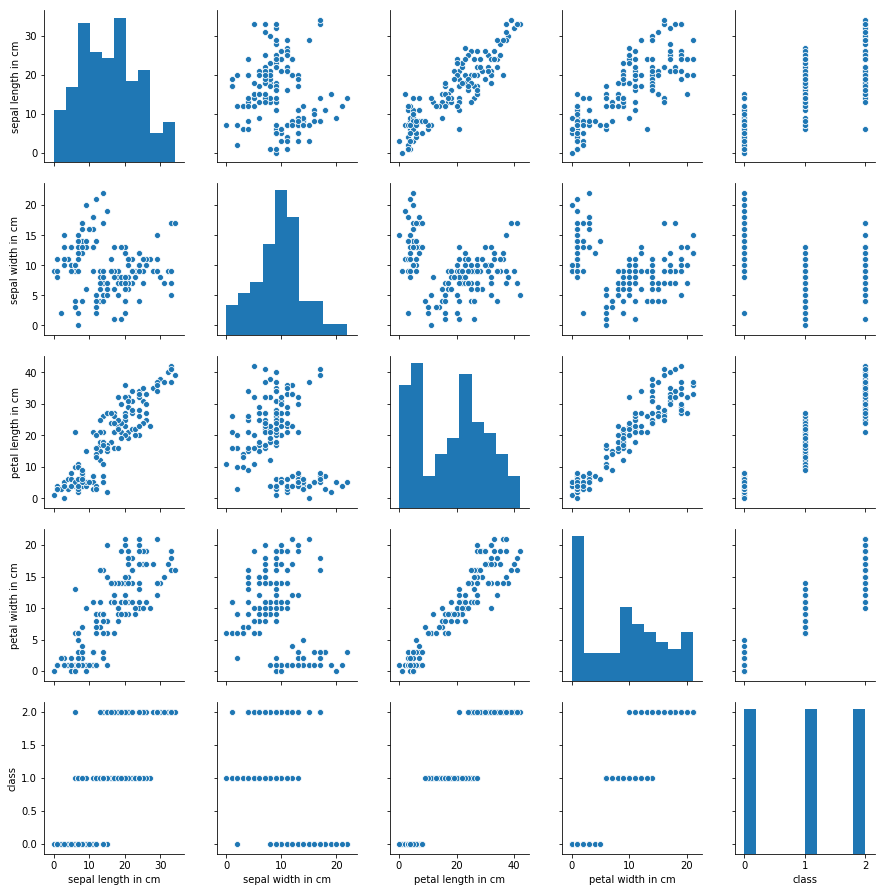

In [442]:
sns.pairplot(df)

## Split the dataset into training and test sets

## Question 7

*Split the dataset into training and test sets with 80-20 ratio.*

In [443]:
test_size = 0.20 # taking 80:20 training and test set
seed = 7  # Random numbmer seeding for reapeatability of the code
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=seed)

## Question 8 - Model

*Build the model and train and test on training and test sets respectively using **scikit-learn**. Print the Accuracy of the model with different values of **k=3,5,9**.*

**Hint:** For accuracy you can check **accuracy_score()** in scikit-learn

In [444]:
NNH3 = KNeighborsClassifier(n_neighbors= 3,weights='uniform', algorithm='auto')

In [445]:
NNH3.fit(X_train, y_train)

KNeighborsClassifier(algorithm='auto', leaf_size=30, metric='minkowski',
           metric_params=None, n_jobs=None, n_neighbors=3, p=2,
           weights='uniform')

In [446]:
predicted_labels3 = NNH3.predict(X_test)

In [447]:
accuracy_score(y_test, predicted_labels3)

0.9

In [448]:
NNH3.score(X_test, y_test)

0.9

In [449]:
NNH5 = KNeighborsClassifier(n_neighbors= 5,weights='uniform', algorithm='auto')

In [450]:
NNH5.fit(X_train, y_train)

KNeighborsClassifier(algorithm='auto', leaf_size=30, metric='minkowski',
           metric_params=None, n_jobs=None, n_neighbors=5, p=2,
           weights='uniform')

In [451]:
predicted_labels5 = NNH5.predict(X_test)

In [452]:
accuracy_score(y_test, predicted_labels5)

0.9

In [453]:
NNH9 = KNeighborsClassifier(n_neighbors= 9,weights='uniform', algorithm='auto')

In [454]:
NNH9.fit(X_train, y_train)

KNeighborsClassifier(algorithm='auto', leaf_size=30, metric='minkowski',
           metric_params=None, n_jobs=None, n_neighbors=9, p=2,
           weights='uniform')

In [455]:
predicted_labels9 = NNH9.predict(X_test)

In [456]:
accuracy_score(y_test, predicted_labels9)

0.8666666666666667

## Question 9 - Cross Validation

Run the KNN with no of neighbours to be 1,3,5..19 and *Find the **optimal number of neighbours** from the above list using the Mis classification error

Hint:

Misclassification error (MSE) = 1 - Test accuracy score. Calculated MSE for each model with neighbours = 1,3,5...19 and find the model with lowest MSE

In [459]:
data=[]
for K in range(19):
 K_value = K+1
 NNH = KNeighborsClassifier(n_neighbors= K_value,weights='uniform', algorithm='auto')
 NNH.fit(X_train, y_train)
 predicted_labels = NNH.predict(X_test)
 accu = accuracy_score(y_test, predicted_labels)
 print ("Accuracy is ",accu, "% for K-Value:",K_value)
 MSE = 1 - metrics.accuracy_score(y_test, predicted_labels)
 print ("Misclassification error (MSE) is ",MSE)
 print ("     ")
 data.append((MSE,K_value))
    
cols=['MSE','K_value']

result = pd.DataFrame(data, columns=cols)
result['MSE'] = result.MSE
result['K_value']=result.K_value

    

Accuracy is  0.9 % for K-Value: 1
Misclassification error (MSE) is  0.09999999999999998
     
Accuracy is  0.8666666666666667 % for K-Value: 2
Misclassification error (MSE) is  0.1333333333333333
     
Accuracy is  0.9 % for K-Value: 3
Misclassification error (MSE) is  0.09999999999999998
     
Accuracy is  0.8666666666666667 % for K-Value: 4
Misclassification error (MSE) is  0.1333333333333333
     
Accuracy is  0.9 % for K-Value: 5
Misclassification error (MSE) is  0.09999999999999998
     
Accuracy is  0.8666666666666667 % for K-Value: 6
Misclassification error (MSE) is  0.1333333333333333
     
Accuracy is  0.8666666666666667 % for K-Value: 7
Misclassification error (MSE) is  0.1333333333333333
     
Accuracy is  0.8666666666666667 % for K-Value: 8
Misclassification error (MSE) is  0.1333333333333333
     
Accuracy is  0.8666666666666667 % for K-Value: 9
Misclassification error (MSE) is  0.1333333333333333
     
Accuracy is  0.8666666666666667 % for K-Value: 10
Misclassification er

### Hight accuracy with loweset MSE
Accuracy is  0.9555555555555556 % for K-Value: 13
Misclassification error (MSE) is  0.0444444444444444

## Question 10

*Plot misclassification error vs k (with k value on X-axis) using matplotlib.*

In [403]:
result.head()

,MSE,K_value
0,0.100000,1
1,0.066667,2
2,0.100000,3
3,0.066667,4
4,0.100000,5


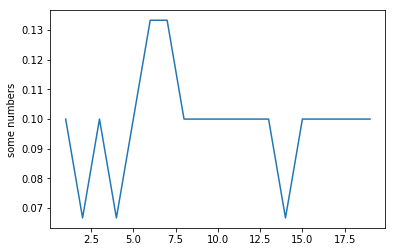

In [404]:

import matplotlib.pyplot as plt
plt.plot(result["K_value"],result["MSE"])
plt.ylabel('some numbers')
plt.show()

# Naive Bayes with Iris Data

In [36]:
#Load all required library
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
%matplotlib inline
from sklearn import datasets
from sklearn.decomposition import PCA
from sklearn.naive_bayes import GaussianNB, BernoulliNB, MultinomialNB


from sklearn.model_selection import train_test_split


### Slice  Iris data set for Independent variables and dependent variables
#### Please note 'Species' is my dependent variables, name it y and independent set data as X

In [405]:
X = df.drop(labels= "class" , axis = 1)

#removed sepal width in cm column since correlation is less less than 0.1 

X1=X.drop(['sepal width in cm'], axis=1)
X1.head()

,sepal length in cm,petal length in cm,petal width in cm
0,5.1,1.4,0.2
1,4.9,1.4,0.2
2,4.7,1.3,0.2
3,4.6,1.5,0.2
4,5.0,1.4,0.2


In [66]:
y1 = df["class"]
y1.head()

0    Iris-setosa
1    Iris-setosa
2    Iris-setosa
3    Iris-setosa
4    Iris-setosa
Name: class, dtype: category
Categories (3, object): [Iris-setosa, Iris-versicolor, Iris-virginica]

In [478]:
#Check the dataset
print(y1)
print(X1)

0         Iris-setosa
1         Iris-setosa
2         Iris-setosa
3         Iris-setosa
4         Iris-setosa
5         Iris-setosa
6         Iris-setosa
7         Iris-setosa
8         Iris-setosa
9         Iris-setosa
10        Iris-setosa
11        Iris-setosa
12        Iris-setosa
13        Iris-setosa
14        Iris-setosa
15        Iris-setosa
16        Iris-setosa
17        Iris-setosa
18        Iris-setosa
19        Iris-setosa
20        Iris-setosa
21        Iris-setosa
22        Iris-setosa
23        Iris-setosa
24        Iris-setosa
25        Iris-setosa
26        Iris-setosa
27        Iris-setosa
28        Iris-setosa
29        Iris-setosa
            ...      
120    Iris-virginica
121    Iris-virginica
122    Iris-virginica
123    Iris-virginica
124    Iris-virginica
125    Iris-virginica
126    Iris-virginica
127    Iris-virginica
128    Iris-virginica
129    Iris-virginica
130    Iris-virginica
131    Iris-virginica
132    Iris-virginica
133    Iris-virginica
134    Iri

# Question 11 
Find the distribution of target variable (Class)

And, Plot the distribution of target variable using histogram

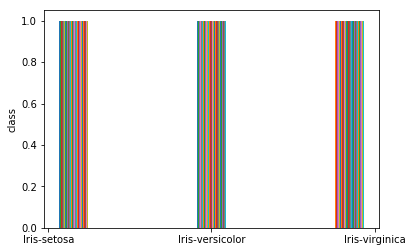

In [479]:
plt.hist(y1, bins=3)
plt.ylabel('class')
plt.show()

### Question 12 
Find Correlation among all variables and give your insights 

In [409]:
#Please note, it's Require to remove correlated features because they are voted twice in the model and 
## it can lead to over inflating importance.We will ignore it here

In [480]:
df['sepal length in cm'] =df['sepal length in cm'].astype('category').cat.codes
df['sepal width in cm'] =df['sepal width in cm'].astype('category').cat.codes
df['petal length in cm'] =df['petal length in cm'].astype('category').cat.codes
df['petal width in cm'] =df['petal width in cm'].astype('category').cat.codes
df['class'] =df['class'].astype('category').cat.codes

In [481]:
df[df.columns[1:]].corr()['class'][:]

sepal width in cm    -0.421028
petal length in cm    0.938885
petal width in cm     0.947668
class                 1.000000
Name: class, dtype: float64

In [72]:
#removed sepal width in cm column since correlation is less less than 0.1 

X1=X.drop(['sepal width in cm'], axis=1)
X1.head()

,sepal length in cm,petal length in cm,petal width in cm
0,5.1,1.4,0.2
1,4.9,1.4,0.2
2,4.7,1.3,0.2
3,4.6,1.5,0.2
4,5.0,1.4,0.2


In [93]:
def score_to_numeric(x):
    if x=='Iris-virginica':
        return 3
    if x=='Iris-versicolor':
        return 2
    if x=='Iris-setosa':
        return 1
y['score_num'] = y['class'].apply(score_to_numeric)
y   

C:\Users\MAYUR-PC\Anaconda3\lib\site-packages\ipykernel_launcher.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy
  


,class,score_num
0,Iris-setosa,1
1,Iris-setosa,1
2,Iris-setosa,1
3,Iris-setosa,1
4,Iris-setosa,1
5,Iris-setosa,1
6,Iris-setosa,1
7,Iris-setosa,1
8,Iris-setosa,1
9,Iris-setosa,1


In [154]:
y['class'].unique()

[Iris-setosa, Iris-versicolor, Iris-virginica]
Categories (3, object): [Iris-setosa, Iris-versicolor, Iris-virginica]

In [156]:
yy=y['score_num']
yy.head(5)

0    1
1    1
2    1
3    1
4    1
Name: score_num, dtype: category
Categories (3, int64): [1, 2, 3]

In [134]:
#yy =yy.astype('category').cat.codes

In [158]:
y2 = pd.get_dummies(y, drop_first=True)


### Split data in Training and test set in 80:20.

In [140]:
test_size = 0.20 # taking 80:20 training and test set
seed = 7  # Random numbmer seeding for reapeatability of the code
X_train, X_test, y_train, y_test = train_test_split(X1, yy, test_size=test_size, random_state=7)

In [141]:
yy.head()

0    0
1    0
2    0
3    0
4    0
dtype: int8

### Question 13 
Do Feature Scaling 

In [142]:
# Use StandardScaler or similar methods


array([[<matplotlib.axes._subplots.AxesSubplot object at 0x0000026A0A8195F8>,
      dtype=object)

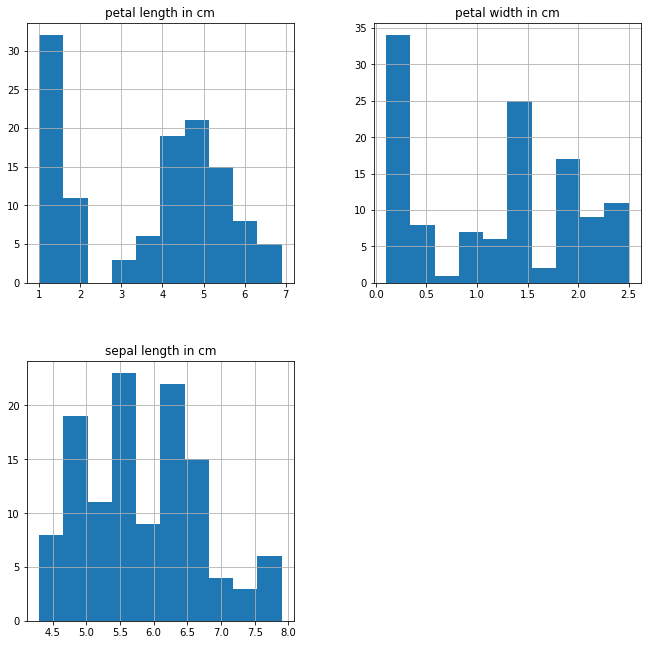

In [143]:
import matplotlib.pyplot as plt
X_train[X_train.dtypes[(X_train.dtypes=="float64")|(X_train.dtypes=="int64")]
                        .index.values].hist(figsize=[11,11])

### Question 14 
Train and Fit NaiveBayes Model

In [144]:
model = GaussianNB()
model.fit(X_train, y_train)
print(model)

GaussianNB(priors=None, var_smoothing=1e-09)


In [145]:
#Predict
predicted = model.predict(X_test)


### Question 15 
Print Accuracy and Confusion Matrix and Conclude your findings

In [146]:
# show Confusion Matrix
metrics.confusion_matrix(predicted, y_test)

array([[ 7,  0,  0],
       [ 0, 10,  2],
       [ 0,  2,  9]], dtype=int64)

In [147]:
#Accuracy
model_score = model.score(X_test, y_test)
model_score

0.8666666666666667

In [148]:
y_predictProb = model.predict_proba(X_test)

In [149]:
# calculate accuracy measures and confusion matrix
from sklearn import metrics
from sklearn.metrics import accuracy_score, confusion_matrix, recall_score, precision_score, f1_score, auc, roc_curve

In [150]:
model_score = model.score(X_test, y_test)
model_score

0.8666666666666667

In [151]:
y_predictProb = model.predict_proba(X_test)

In [153]:
#Show precision and Recall metrics


# For Practice  - Optional

All the questions from 16 to 20 are for practice.

# Using SVM with Diebetes Dataset

In [0]:
#Import library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# Question 16 
Read the input file 'Diabetes.csv' using Pandas and check it's column names.

Check dimension of dataset.

Check distribution of dependent variable, Outcome and plot it.


In [0]:
# Eye ball the imported dataset

### Out of  768 data points, 500 are labeled as 0 and 268 as 1.
### Outcome 0 means No diabetes, outcome 1 means diabetes

In [0]:
# Check data types and info of dataset

# Question 17 
Check data distribution using summary statistics and provide your findings.

Do correlation analysis and bivariate viualization with Insights


# Question 18 
Do train and test split. 
Optionally - You can do with stratify sampling(optional) on Outcome variable to maintain the distribution of dependent variable

# Question 19 
Train Support Vector Machine Model(1 Marks)

In [0]:
# use from sklearn.svm import SVC

In [0]:
# your insights

# Question 20
Scale the data points using MinMaxScaler

Fit SVM Model on Scale data and give your observation

#we can try increasing either C or gamma to fit a more complex model.

# Optional Question - 
Try improving the model accuracy using C=1000 (1 Marks)

### Here, increasing C allows us to improve the model, resulting in ??? accuracy.
### Let's try to explore different Kernel and C (Bonus for practice)

In [0]:
import multiprocessing 
from sklearn.model_selection import GridSearchCV

In [0]:
 param_grid = [    {        
     'kernel': ['linear', 'rbf', 'poly', 'sigmoid'],        
     'C': [ 0.1, 0.2, 0.4, 0.5, 1.0, 1.5, 1.8, 2.0, 2.5, 3.0 ]    } ]

In [0]:
gs = GridSearchCV(estimator=SVC(), param_grid=param_grid,scoring='accuracy', cv=10, n_jobs=multiprocessing.cpu_count())

In [0]:
gs.fit(X_train_scaled, y_train) 

GridSearchCV(cv=10, error_score='raise',
       estimator=SVC(C=1.0, cache_size=200, class_weight=None, coef0=0.0,
  decision_function_shape=None, degree=3, gamma='auto', kernel='rbf',
  max_iter=-1, probability=False, random_state=None, shrinking=True,
  tol=0.001, verbose=False),
       fit_params={}, iid=True, n_jobs=4,
       param_grid=[{'kernel': ['linear', 'rbf', 'poly', 'sigmoid'], 'C': [0.1, 0.2, 0.4, 0.5, 1.0, 1.5, 1.8, 2.0, 2.5, 3.0]}],
       pre_dispatch='2*n_jobs', refit=True, return_train_score=True,
       scoring='accuracy', verbose=0)

In [0]:
gs.best_estimator_

SVC(C=2.5, cache_size=200, class_weight=None, coef0=0.0,
  decision_function_shape=None, degree=3, gamma='auto', kernel='linear',
  max_iter=-1, probability=False, random_state=None, shrinking=True,
  tol=0.001, verbose=False)

In [0]:
gs.best_score_ 

0.77777777777777779